**Task** **1**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [ ]:
# Load image
image = mpimg.imread("lung_ct.jpg")
lung_ct_array =image

In [ ]:
image.shape

(426, 640)

In [ ]:
# Report the size of the image
width, height = image.size
print(f"The size of the image is {width}×{height} pixels.")

The size of the image is 640×426 pixels.


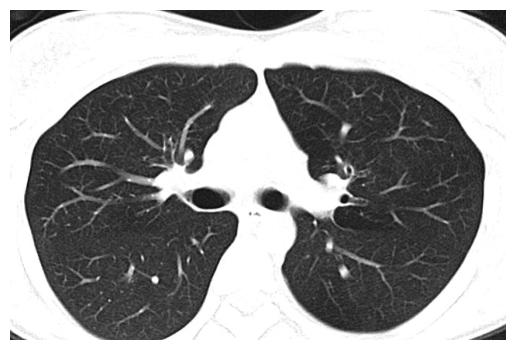

In [ ]:
image = Image.open('lung_ct.jpg').convert('L')

# Display the image
plt.imshow(image, cmap='gray')
plt.axis('off')  # Turn off axis numbers
plt.show()


Task **2**

In [ ]:
# Compute the 2D FFT
fft_result = np.fft.fft2(image)


In [ ]:
# Compute magnitude and phase
magnitude = np.abs(fft_result)
phase = np.angle(fft_result)

In [ ]:
# Apply fftshift
magnitude_shifted = np.fft.fftshift(magnitude)
phase_shifted = np.fft.fftshift(phase)

In [ ]:
# Use log scale for magnitude if it produces more informative results
magnitude_log = np.log1p(magnitude)
magnitude_shifted_log = np.log1p(magnitude_shifted)


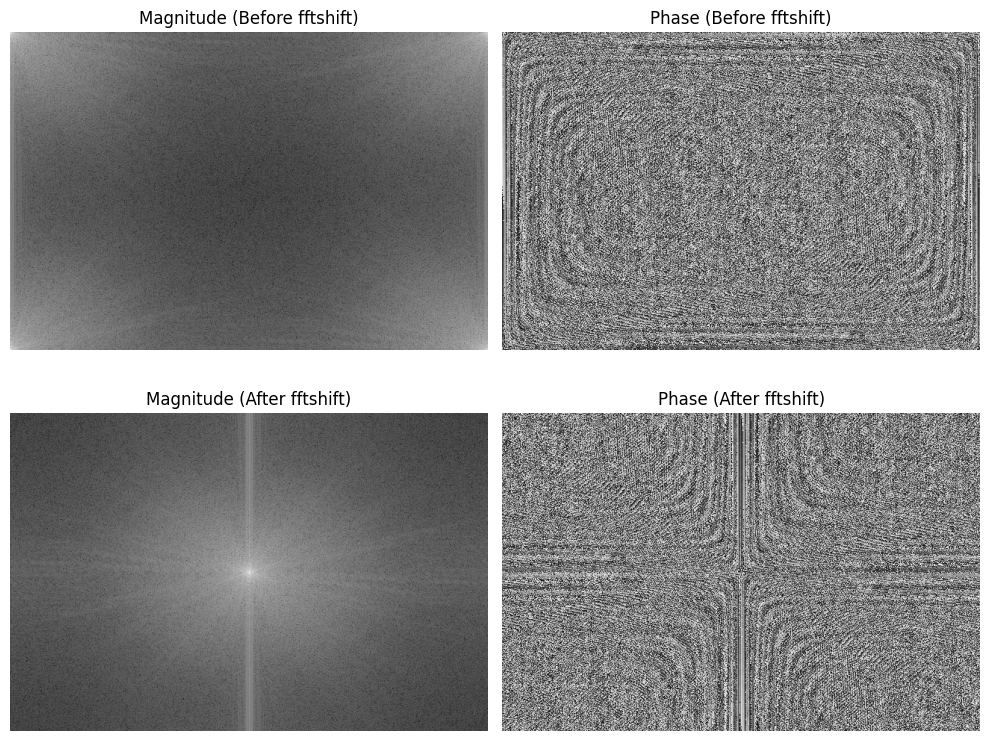

In [ ]:
# Display the images using matplotlib
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# Display magnitude before fftshift
ax[0, 0].imshow(np.log1p(magnitude), cmap='gray')
ax[0, 0].set_title('Magnitude (Before fftshift)')
ax[0, 0].axis('off')

# Display phase before fftshift
ax[0, 1].imshow(phase, cmap='gray')
ax[0, 1].set_title('Phase (Before fftshift)')
ax[0, 1].axis('off')

# Display magnitude after fftshift
ax[1, 0].imshow(np.log1p(magnitude_shifted), cmap='gray')
ax[1, 0].set_title('Magnitude (After fftshift)')
ax[1, 0].axis('off')

# Display phase after fftshift
ax[1, 1].imshow(phase_shifted, cmap='gray')
ax[1, 1].set_title('Phase (After fftshift)')
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

Task **3**

<ipython-input-12-aeffe0110887>:2: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  downsampled_image = image.resize((width // 2, height // 2), Image.ANTIALIAS)


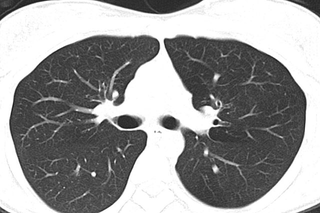

In [ ]:
# Downsample the image to half size
downsampled_image = image.resize((width // 2, height // 2), Image.ANTIALIAS)
downsampled_image
#downsampled_image.size

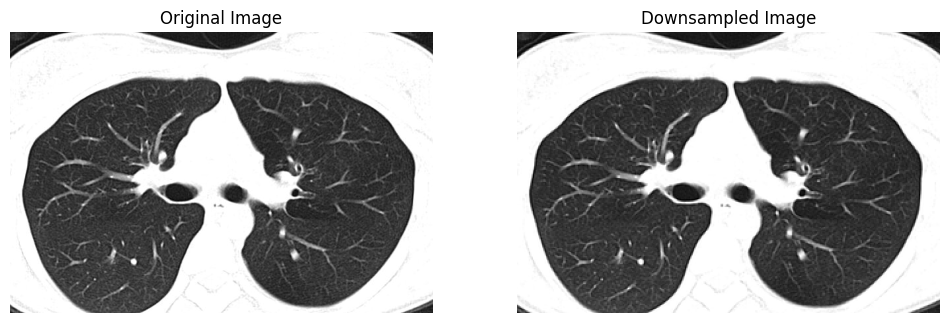

In [ ]:
plt.figure(figsize=(12, 6))
# Displaying the original image
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')  # Turn off axis numbers
# Displaying the downsampled image
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
plt.imshow(downsampled_image, cmap='gray')
plt.title('Downsampled Image')
plt.axis('off')  # Turn off axis numbers

plt.show()

In [ ]:
# Report the size of the image
width, height = downsampled_image.size
print(f"The size of the image is {width}×{height} pixels.")

The size of the image is 320×213 pixels.


**Task** **4**

In [ ]:
# Convert the downsampled image to a NumPy array
downsampled_array = np.array(downsampled_image)

In [ ]:
# Compute the 2D FFT of the downsampled image
fft2_downsampled = np.fft.fft2(downsampled_array)
fft2_shifted = np.fft.fftshift(fft2_downsampled)  # Center the zero frequency component


In [ ]:

# The size of the original image
original_shape = lung_ct_array.shape

In [ ]:

# Calculate the amount of zero-padding needed
padding = [(0, 0)] * 2  # initialize with no padding
for axis in range(2):
    pad_size = original_shape[axis] - downsampled_array.shape[axis]
    pad_before = pad_size // 2
    pad_after = pad_size - pad_before
    padding[axis] = (pad_before, pad_after)



In [ ]:
# Apply zero-padding while maintaining conjugate symmetry
padded_fft2_shifted = np.pad(fft2_shifted, padding, mode='constant', constant_values=(0, 0))


In [ ]:

# Shift back and perform the inverse 2D FFT
padded_fft2 = np.fft.ifftshift(padded_fft2_shifted)
interpolated_array = np.fft.ifft2(padded_fft2).real


In [ ]:
# Normalize the interpolated image for display
interpolated_image_normalized = (interpolated_array - np.min(interpolated_array)) / (np.max(interpolated_array) - np.min(interpolated_array))

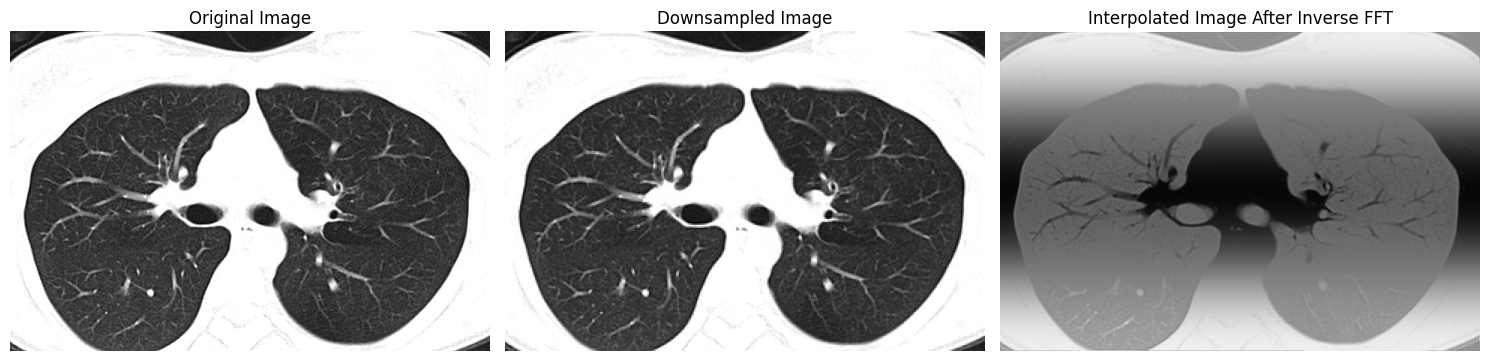

In [ ]:


# Display the original, downsampled, and interpolated images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Original image
ax[0].imshow(lung_ct_array, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Downsampled image
ax[1].imshow(downsampled_array, cmap='gray')
ax[1].set_title('Downsampled Image')
ax[1].axis('off')

# Interpolated image after inverse FFT
ax[2].imshow(interpolated_image_normalized, cmap='gray')
ax[2].set_title('Interpolated Image After Inverse FFT')
ax[2].axis('off')

plt.tight_layout()
plt.show()



Task **5**

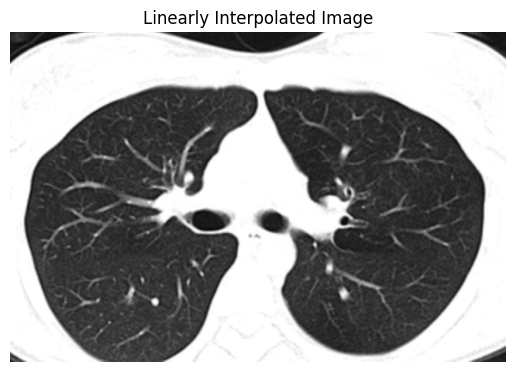

In [ ]:

# Perform linear interpolation on the downsampled image to bring it back to the original size with BILINEAR function
linear_interpolated_image = downsampled_image.resize(image.size, Image.BILINEAR)

# Display the linear interpolated image
plt.imshow(linear_interpolated_image, cmap='gray')
plt.title('Linearly Interpolated Image')
plt.axis('off')
plt.show()


**Task** **6**

In [ ]:
from sklearn.metrics import mean_squared_error

# Convert the interpolated images to arrays for error computation
interpolated_array_fft = np.array(interpolated_image_normalized)
linear_interpolated_array = np.array(linear_interpolated_image)

# Compute the mean squared errors
mse_fft = mean_squared_error(lung_ct_array, interpolated_array_fft)
mse_linear = mean_squared_error(lung_ct_array, linear_interpolated_array)

mse_fft, mse_linear



(31734.19825920962, 18.426811913145542)

The error between the **original** **image** and the **image interpolated using FFT**: approximately 31734.20.
The error between the **original image** and the **image interpolated using linear (bilinear) interpolation**: approximately 18.43.
These values indicate the average of the squares of the differences between the original and interpolated images, providing a measure of the quality of the interpolation. In this case, linear interpolation has resulted in a much closer approximation to the original image compared to the FFT-based interpolation